In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os
from os import listdir
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, auc, roc_auc_score, roc_curve
from sklearn import preprocessing

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Dans weather2 ils utilisent VGG16, on garde (même si ResNet marche aussi)
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2026-01-19 16:23:30.745738: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-19 16:23:30.816092: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-19 16:23:34.272832: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Num GPUs Available:  0


2026-01-19 16:23:35.062846: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

TF version: 2.20.0
Num GPUs Available: 0


In [3]:
# (création data/data_test)

# 1) Charger le CSV Flipkart (si pas déjà fait dans ce notebook)
df = pd.read_csv("flipkart_com-ecommerce_sample_1050.csv")

# 2) Construire image_path + has_image (si pas déjà fait)
IMAGE_DIR = "Images"

def build_image_path(filename):
    if pd.isna(filename):
        return None
    return os.path.join(IMAGE_DIR, filename)

df["image_path"] = df["image"].apply(build_image_path)
df["has_image"] = df["image_path"].apply(lambda p: p is not None and os.path.exists(p))

# 3) Sous-ensemble avec images
df_img = df[df["has_image"]].copy().reset_index(drop=True)
print("df_img shape :", df_img.shape)

# 4) Colonne catégorie (chez toi : product_category_tree)
category_col = "product_category_tree"

# label_name = catégorie texte (comme weather2)
df_img["label_name"] = df_img[category_col]

# 5) main_class = catégorie principale (7 classes)
df_img["main_class"] = df_img["label_name"].apply(lambda x: x.split(">>")[0].strip())

print("Nb main_class :", df_img["main_class"].nunique())
print(df_img["main_class"].value_counts())

# 6) Split train/test (équivalent aux deux dossiers weather2)
data, data_test = train_test_split(
    df_img[["image_path", "main_class"]].copy(),
    test_size=0.2,
    random_state=42,
    stratify=df_img["main_class"]
)

data = data.reset_index(drop=True)
data_test = data_test.reset_index(drop=True)

# 7) Encoder les labels numériques comme weather2
le = preprocessing.LabelEncoder()
le.fit(data["main_class"])  # on fit sur train

data["label_name"] = data["main_class"]
data_test["label_name"] = data_test["main_class"]

data["label"] = le.transform(data["label_name"])
data_test["label"] = le.transform(data_test["label_name"])

print("Train:", data.shape, "| Test:", data_test.shape)
data_test.head(5)


df_img shape : (1050, 17)
Nb main_class : 7
main_class
["Home Furnishing               150
["Baby Care                     150
["Watches                       150
["Home Decor & Festive Needs    150
["Kitchen & Dining              150
["Beauty and Personal Care      150
["Computers                     150
Name: count, dtype: int64
Train: (840, 4) | Test: (210, 4)


,image_path,main_class,label_name,label
0,Images/3dfd14b667357e26ff6d66761cdc203f.jpg,"[""Baby Care","[""Baby Care",0
1,Images/17a73d7c4b02ada2bfeed1115fed08a4.jpg,"[""Beauty and Personal Care","[""Beauty and Personal Care",1
2,Images/597a9549a3e397d52dca62ee47b1f60a.jpg,"[""Home Furnishing","[""Home Furnishing",4
3,Images/24e85c590481a7cedfe66597f253f2b2.jpg,"[""Beauty and Personal Care","[""Beauty and Personal Care",1
4,Images/59d964c38c787f829c6cfa5629e4df90.jpg,"[""Beauty and Personal Care","[""Beauty and Personal Care",1


In [4]:
data.groupby("label").count()["image_path"]

label
0    120
1    120
2    120
3    120
4    120
5    120
6    120
Name: image_path, dtype: int64

In [5]:
# Catégorie principale (niveau 1) : ex "Kitchen & Dining"
data["main_class"] = data["label_name"].apply(lambda s: s.split(">>")[0].strip() if isinstance(s, str) else s)

list_labels = sorted(data["main_class"].unique())
print("Nb catégories:", len(list_labels))
print(list_labels)

Nb catégories: 7
['["Baby Care', '["Beauty and Personal Care', '["Computers', '["Home Decor & Festive Needs', '["Home Furnishing', '["Kitchen & Dining', '["Watches']


["Baby Care (n=120)


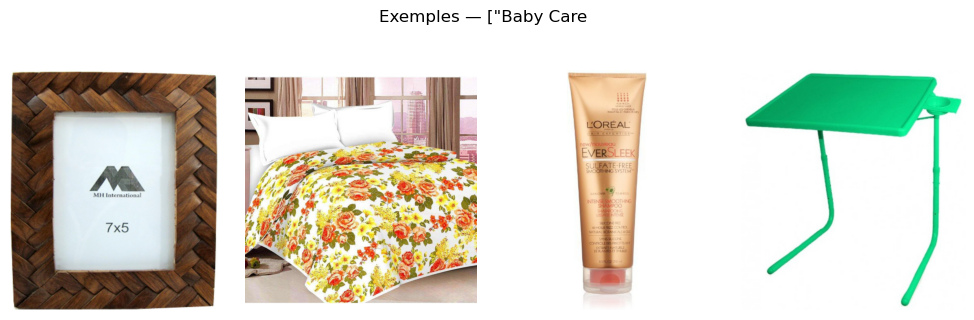

["Beauty and Personal Care (n=120)


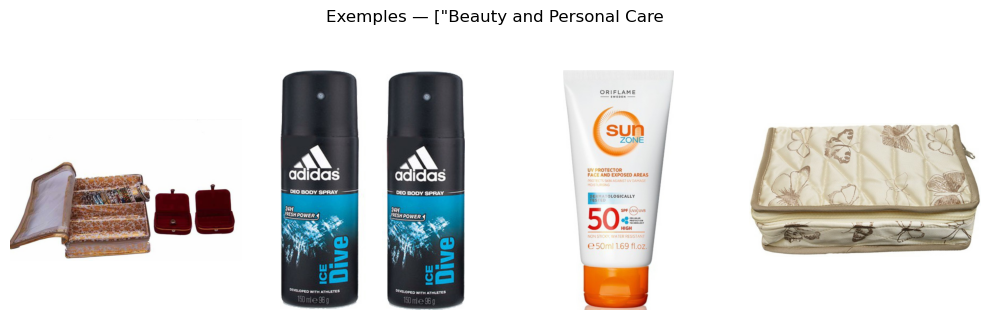

["Computers (n=120)


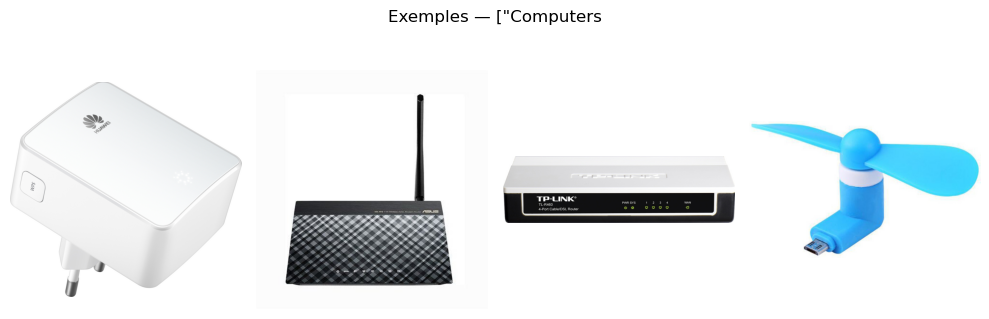

["Home Decor & Festive Needs (n=120)


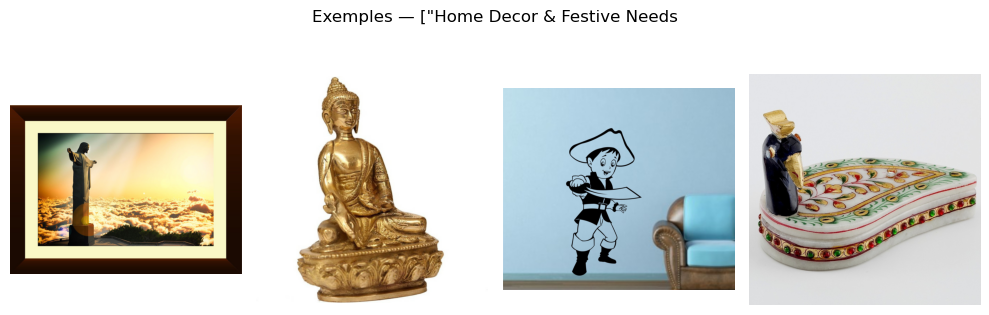

["Home Furnishing (n=120)


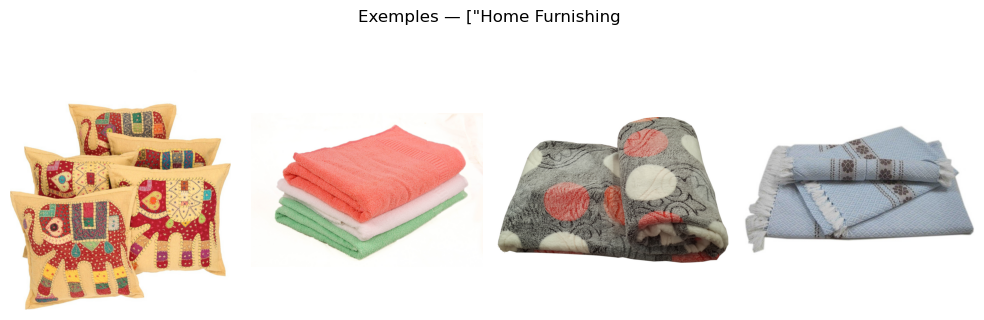

["Kitchen & Dining (n=120)


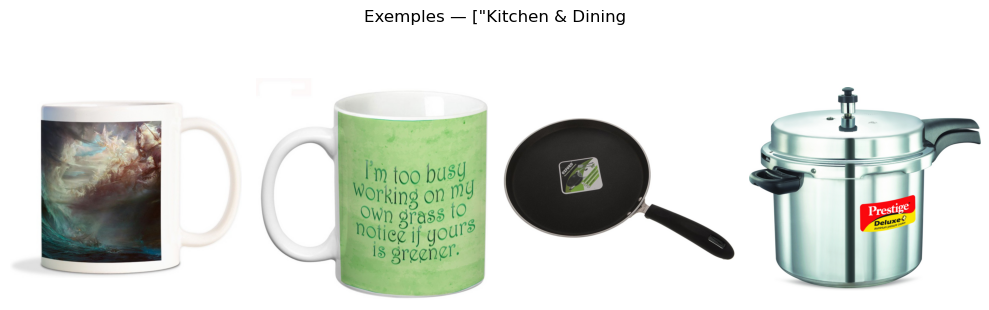

["Watches (n=120)


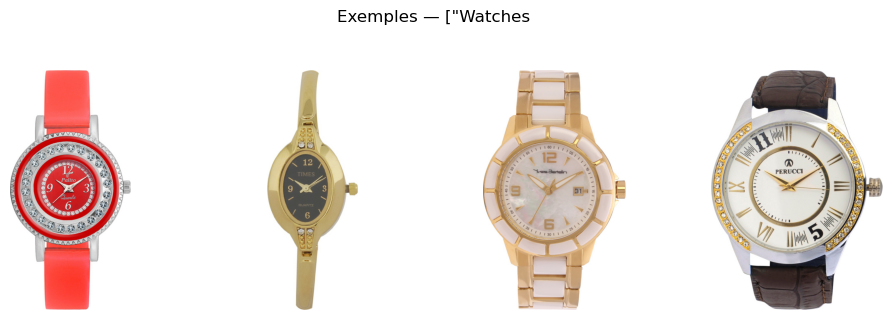

In [6]:
# Code “Weather2-like” : afficher 4 images par catégorie (sans tout charger)

import matplotlib.pyplot as plt
from matplotlib.image import imread
import numpy as np

# Choisis la colonne de classe à utiliser :
# - si label_name = déjà 7 catégories -> utilise "label_name"
# - si label_name = hiérarchie longue -> utilise "main_class"
label_col = "main_class" if "main_class" in data.columns else "label_name"

def list_fct(name):
    # liste des chemins pour une classe donnée
    return data.loc[data[label_col] == name, "image_path"].tolist()

n_show = 4      # nombre d'images par catégorie
start_at = 0    # comme i+10 dans l'exemple, mets 10 si tu veux "sauter" les premières

for name in list_labels:
    paths = list_fct(name)

    print(name, f"(n={len(paths)})")

    # Sécurité : si pas assez d’images
    if len(paths) == 0:
        print("aucune image")
        continue

    # on ne prend que n_show images (et on peut démarrer à start_at)
    sel = paths[start_at:start_at + n_show]
    if len(sel) < n_show:
        sel = paths[:n_show]  # fallback

    plt.figure(figsize=(10, 3))
    for i, filename in enumerate(sel):
        plt.subplot(1, n_show, i + 1)
        try:
            img = imread(filename)   # charge seulement cette image
            plt.imshow(img)
        except Exception as e:
            plt.text(0.5, 0.5, "Erreur\nlecture", ha="center", va="center")
        plt.axis("off")

    plt.suptitle(f"Exemples — {name}", y=1.05, fontsize=12)
    plt.tight_layout()
    plt.show()

------------Etape 1 : étude de faisabilité--------------

Création du modèle pré-entraîné

In [7]:
# Création du modèle pré-entraîné (VGG16)

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model

# 1) Charger VGG16 pré-entraîné ImageNet
base_model = VGG16(weights="imagenet", include_top=True)  # comme dans l'exemple

# 2) Sortie = avant-dernière couche (fc2) -> vecteur 4096
# (dans VGG16 include_top=True : ... flatten -> fc1 -> fc2 -> predictions)
model = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)

print(model.summary())
print("Dimension embedding :", model.output_shape)  # (None, 4096)

2026-01-19 16:23:40.270475: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 411041792 exceeds 10% of free system memory.
2026-01-19 16:23:40.624458: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 411041792 exceeds 10% of free system memory.
2026-01-19 16:23:40.770271: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 411041792 exceeds 10% of free system memory.
2026-01-19 16:23:43.633116: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 411041792 exceeds 10% of free system memory.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None
Dimension embedding : (None, 4096)


In [8]:
# “freeze” le modèle

for layer in base_model.layers:
    layer.trainable = False

In [9]:
# test sur 1 image Flipkart

# Ça permet de valider que le modèle marche avant de lancer tout le dataset.

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

# Choisis une image existante
img_path = data["image_path"].iloc[0]  # ou df_img["image_path"].iloc[0]

img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

vec = model.predict(x, verbose=0)
print("Embedding shape :", vec.shape)   # (1, 4096)

Embedding shape : (1, 4096)


Création des features des images

In [10]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

images_features = []
valid_paths = []   # pour garder l’alignement avec les labels
i = 0

for image_file in data["image_path"]:
    if i % 100 == 0:
        print(i)
    i += 1

    try:
        image = load_img(image_file, target_size=(224, 224))  # resize
        image = img_to_array(image)
        image = np.expand_dims(image, axis=0)
        image = preprocess_input(image)

        images_features.append(model.predict(image, verbose=0)[0])  # vecteur (4096,)
        valid_paths.append(image_file)

    except Exception as e:
        # si une image est illisible/corrompue, on skip
        continue

images_features = np.asarray(images_features)

print("images_features shape :", images_features.shape)
print("nb images valides :", len(valid_paths))

0
100
200
300
400
500
600
700


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


800
images_features shape : (840, 4096)
nb images valides : 840


In [11]:
data_valid = data[data["image_path"].isin(valid_paths)].copy().reset_index(drop=True)
print("data_valid shape :", data_valid.shape)

data_valid shape : (840, 4)


--------------Réduction dimension et analyse------------

Réduction de dimension PCA

In [12]:
# Réduction de dimension PCA (99% variance)

from sklearn import decomposition

print("Dimensions avant PCA :", images_features.shape)

pca = decomposition.PCA(n_components=0.99, random_state=42)
feat_pca = pca.fit_transform(images_features)

print("Dimensions après PCA :", feat_pca.shape)

Dimensions avant PCA : (840, 4096)
Dimensions après PCA : (840, 660)


In [13]:
print("Variance expliquée cumulée :", pca.explained_variance_ratio_.sum())
print("Nb composantes retenues :", pca.n_components_)

Variance expliquée cumulée : 0.9900038
Nb composantes retenues : 660


Réduction de dimension T-SNE et affichage des images selon vraies classes

In [14]:
# T-SNE (2D) + temps de calcul

from sklearn import manifold
import time

temps1 = time.time()

tsne = manifold.TSNE(
    n_components=2,
    perplexity=30,
    max_iter=2000,      # n_iter -> max_iter (versions récentes sklearn)
    init="random",
    random_state=6
)

X_tsne = tsne.fit_transform(feat_pca)

duration1 = time.time() - temps1
print("temps de T-SNE : ", "%15.2f" % duration1, "secondes")
print("X_tsne shape :", X_tsne.shape)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


temps de T-SNE :            22.64 secondes
X_tsne shape : (840, 2)


df_tsne shape : (840, 3)
class
["Home Furnishing               120
["Computers                     120
["Kitchen & Dining              120
["Baby Care                     120
["Home Decor & Festive Needs    120
["Beauty and Personal Care      120
["Watches                       120
Name: count, dtype: int64


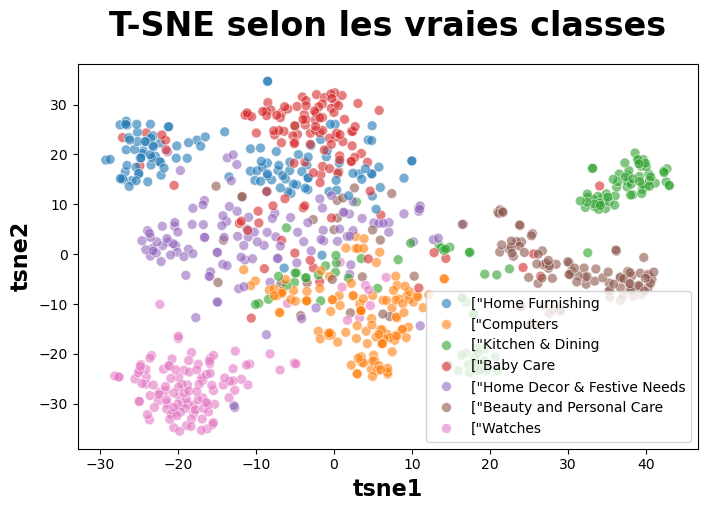

In [15]:
# T-SNE selon les vraies classes (version robuste)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sécurité alignement longueurs
n_tsne = X_tsne.shape[0]
labels = data["label_name"].iloc[:n_tsne].values

# DataFrame TSNE
df_tsne = pd.DataFrame(X_tsne, columns=["tsne1", "tsne2"])
df_tsne["class"] = labels

print("df_tsne shape :", df_tsne.shape)
print(df_tsne["class"].value_counts())

# Plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="tsne1",
    y="tsne2",
    hue="class",
    palette=sns.color_palette("tab10", n_colors=df_tsne["class"].nunique()),
    s=50,
    alpha=0.6,
    data=df_tsne,
    legend="brief"
)

plt.title("T-SNE selon les vraies classes", fontsize=24, pad=20, fontweight="bold")
plt.xlabel("tsne1", fontsize=16, fontweight="bold")
plt.ylabel("tsne2", fontsize=16, fontweight="bold")
plt.legend(prop={"size": 10})
plt.show()

️Séparation globale des classes — faisabilité validée (On observe une structuration claire des points par catégories principales) (cela montre que les features extraites par VGG16 contiennent une information sémantique exploitable pour distinguer les classes.)

Classes bien séparées (Les catégories suivantes sont visuellement bien discriminées) (Cela suggère qu’un modèle supervisé CNN atteindra probablement une bonne précision sur ces catégories.)

Zones de confusion partielle, on observe des chevauchements (Ces catégories partagent des textures, formes et contextes visuels similaires eteaucoup d’objets sont “indoor / lifestyle / produit sur fond neutre”) (ces classes sont sémantiquement proches, ce qui rend la séparation plus difficile.)

Densité et régularité des points (Chaque cluster a une densité comparable et le T-SNE n’est pas biaisé par une classe dominante) (C’est excellent méthodologiquement pour démontrer la faisabilité.)

L’analyse T-SNE basée sur les features extraites par un modèle pré-entraîné (VGG16) montre que les images se structurent naturellement selon leurs catégories principales.
Cela valide la faisabilité d’une classification supervisée basée sur du deep learning, avec un potentiel de performance élevé pour les classes visuellement distinctes.

L’analyse graphique T-SNE montre que les représentations extraites par VGG16 permettent une structuration naturelle des images selon leurs catégories principales.
Certaines classes comme Baby Care, Computers et Watches sont clairement séparées, tandis que des catégories visuellement proches (Home Furnishing, Home Decor & Festive Needs, Kitchen & Dining) présentent des zones de recouvrement.

Cette étape valide la faisabilité d’une classification supervisée et justifie la mise en place d’un modèle CNN pour la prédiction automatique des catégories produits.

In [16]:
# KMeans sur la sortie TSNE (clusters “théoriques”)

from sklearn import cluster, metrics

# Nombre de clusters = nb de catégories principales
k = df_tsne["main_class"].nunique() if "main_class" in df_tsne.columns else df_tsne["class"].nunique()
print("Nombre de clusters (k) :", k)

cls = cluster.KMeans(n_clusters=k, n_init=100, random_state=6)
cls.fit(X_tsne)

# Ajout des labels de cluster dans df_tsne
df_tsne["cluster"] = cls.labels_

print("df_tsne shape :", df_tsne.shape)
df_tsne["cluster"].value_counts().sort_index()

Nombre de clusters (k) : 7
df_tsne shape : (840, 4)


cluster
0    115
1    160
2    123
3     62
4    107
5    112
6    161
Name: count, dtype: int64

In [17]:
# Calcul de l’ARI (mesure qui “confirme” le visuel)

from sklearn.preprocessing import LabelEncoder

# On choisit la colonne de vérité terrain (main_class si dispo, sinon class)
true_col = "main_class" if "main_class" in df_tsne.columns else "class"

le = LabelEncoder()
y_true = le.fit_transform(df_tsne[true_col])

ari = metrics.adjusted_rand_score(y_true, df_tsne["cluster"])
print(f"ARI (T-SNE clusters vs {true_col}) : {ari:.3f}")

ARI (T-SNE clusters vs class) : 0.457


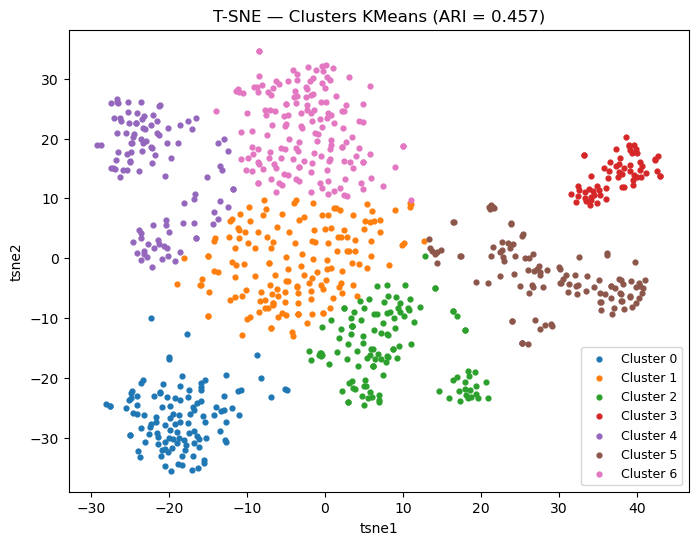

In [18]:
# Affichage TSNE selon les clusters (comme Weather2)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for c in sorted(df_tsne["cluster"].unique()):
    sub = df_tsne[df_tsne["cluster"] == c]
    plt.scatter(sub["tsne1"], sub["tsne2"], s=12, label=f"Cluster {c}")

plt.title(f"T-SNE — Clusters KMeans (ARI = {ari:.3f})")
plt.xlabel("tsne1")
plt.ylabel("tsne2")
plt.legend(fontsize=9)
plt.show()


- PROBLEME :

class = catégorie complète (long texte)

main_class = catégorie principale (ex: "Kitchen & Dining")

cluster = cluster KMeans

- SOLUTION : 

Choisir une catégorie réelle

Choisir un cluster à analyser

Extraire les images qui sont “mal classées” visuellement

In [19]:
# Créer main_class à partir de df_tsne["class"]
import re

def extract_main_class(s: str) -> str:
    s = str(s)
    # enlever crochets/guillemets éventuels
    s = s.strip()
    s = re.sub(r'^\[\"|\[\'|\"?\]$|\'?\]$', '', s)  # nettoyages basiques
    s = s.replace('["', '').replace('"]', '').replace("[", "").replace("]", "").strip()
    # si "A >> B >> C", garder "A"
    return s.split(">>")[0].strip()

df_tsne["main_class"] = df_tsne["class"].apply(extract_main_class)

print(df_tsne["main_class"].value_counts())

main_class
Home Furnishing               120
Computers                     120
Kitchen & Dining              120
Baby Care                     120
Home Decor & Festive Needs    120
Beauty and Personal Care      120
Watches                       120
Name: count, dtype: int64


In [20]:
# Adaptée Flipkart

# Analyse d’images d’une vraie catégorie affectées à un cluster donné

target_class = "Kitchen & Dining"
target_cluster = 3

list_misclassified = [
    i for i in range(len(df_tsne))
    if (df_tsne.iloc[i]["main_class"] == target_class)
    and (df_tsne.iloc[i]["cluster"] == target_cluster)
]

print("Nombre d’images concernées :", len(list_misclassified))
list_misclassified[:5]

Nombre d’images concernées : 61


[2, 23, 47, 97, 112]

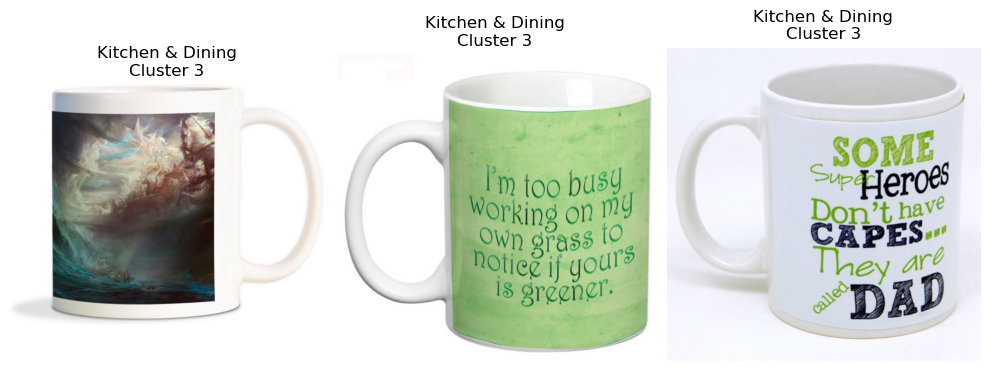

In [21]:
# Affichage des images correspondantes

from matplotlib.image import imread
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for idx, i in enumerate(list_misclassified[:3]):
    plt.subplot(1, 3, idx+1)

    # Ici on utilise data, pas df_sift
    img_path = data.iloc[i]["image_path"]
    img = imread(img_path)

    plt.imshow(img)
    plt.title(f"{target_class}\nCluster {target_cluster}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# Trouve le cluster majoritaire pour chaque classe principale
mapping = (
    df_tsne
    .groupby(["main_class", "cluster"])
    .size()
    .reset_index(name="count")
    .sort_values(["main_class", "count"], ascending=[True, False])
    .drop_duplicates("main_class")
)

print(mapping)

                    main_class  cluster  count
5                    Baby Care        6     88
9     Beauty and Personal Care        5     95
12                   Computers        2     85
14  Home Decor & Festive Needs        1     67
21             Home Furnishing        6     62
24            Kitchen & Dining        3     61
27                     Watches        0    111


Sélection d’une image : id = 220

Affichage des métadonnées : print(df_tsne.iloc[id])

Récupération du fichier image : filename = data.iloc[id]["image_path"]

Infos TSNE :
tsne1                            16.606268
tsne2                             5.993664
class         ["Home Decor & Festive Needs
cluster                                  5
main_class      Home Decor & Festive Needs
Name: 220, dtype: object



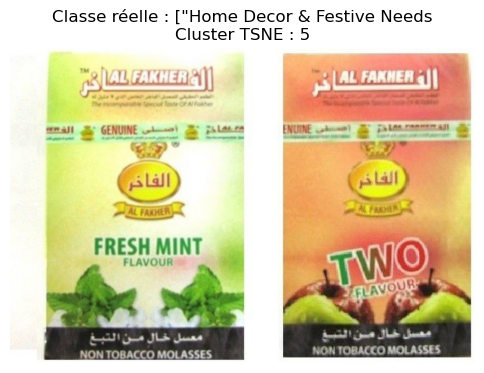

In [23]:
# Affichage d'une image donnée avec ses infos TSNE / cluster

from matplotlib.image import imread
import matplotlib.pyplot as plt

id = 220   # index de l'image à analyser

# Infos TSNE / cluster / classe réelle
print("Infos TSNE :")
print(df_tsne.iloc[id])
print()

# Chargement image depuis data (aligné avec df_tsne)
filename = data.iloc[id]["image_path"]
image = imread(filename)

# Affichage
plt.figure(figsize=(6,5))
plt.imshow(image)
plt.title(
    f"Classe réelle : {df_tsne.iloc[id]['class']}\n"
    f"Cluster TSNE : {df_tsne.iloc[id]['cluster']}"
)
plt.axis("off")
plt.show()

Cette visualisation permet d’analyser individuellement des images projetées dans une zone du T-SNE correspondant à un cluster dominant d’une autre catégorie.
Elle met en évidence des similarités visuelles entre catégories, telles que des fonds clairs, des formes cylindriques ou des compositions proches, pouvant expliquer certaines confusions observées dans la matrice de confusion et la valeur modérée de l’ARI.

In [24]:
# “conf_mat”

from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1) Vraies classes -> encodage numérique (obligatoire pour la confusion matrix)
le = LabelEncoder()
labels = le.fit_transform(df_tsne["class"])   # df_tsne["class"] = label_name (catégorie réelle)

# 2) Clusters TSNE (KMeans)
y_pred = df_tsne["cluster"].values           # ou cls.labels_ si tu utilises la variable cls

# 3) Matrice de confusion
conf_mat = metrics.confusion_matrix(labels, y_pred)

print(conf_mat)
print("\nClasses (ordre des lignes) :", list(le.classes_))
print("Clusters (ordre des colonnes) :", sorted(np.unique(y_pred)))

[[  0  18   2   1   7   4  88]
 [  0  12   4   0   3  95   6]
 [  0  35  85   0   0   0   0]
 [  4  67   1   0  42   2   4]
 [  0   3   0   0  55   0  62]
 [  0  21  26  61   0  11   1]
 [111   4   5   0   0   0   0]]

Classes (ordre des lignes) : ['["Baby Care', '["Beauty and Personal Care', '["Computers', '["Home Decor & Festive Needs', '["Home Furnishing', '["Kitchen & Dining', '["Watches']
Clusters (ordre des colonnes) : [0, 1, 2, 3, 4, 5, 6]


strictement fidèle au notebook Weather2 : df_tsne["class"] = data["label_name"].values

label_name pour moi = catégories fines Flipkart

Donc 200+ classes, et les matrices + reports seront illisibles

In [25]:
print("Nb classes :", df_tsne["class"].nunique())
print("Nb points TSNE :", len(df_tsne))

Nb classes : 7
Nb points TSNE : 840


In [26]:
import ast
import os

def extract_main_class(tree_str):
    try:
        lst = ast.literal_eval(tree_str)
        if isinstance(lst, list) and len(lst) > 0:
            return lst[0].split(" >> ")[0].strip()
    except Exception:
        pass

    if isinstance(tree_str, str) and ">>" in tree_str:
        return tree_str.split(">>")[0].strip()

    return "Unknown"

# 1) S'assurer que df_img a bien product_category_tree
print("Colonnes df_img:", df_img.columns)

df_img["main_class"] = df_img["product_category_tree"].apply(extract_main_class)

# 2) Construire data à partir de df_img (aligné)
data = df_img[["image_path", "main_class"]].copy()
data = data.reset_index(drop=True)

# 3) Pour rester "fidèle weather2", on appelle ça label_name
data["label_name"] = data["main_class"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["label"] = le.fit_transform(data["label_name"])

data.head()

Colonnes df_img: Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications', 'image_path',
       'has_image', 'label_name', 'main_class'],
      dtype='object')


,image_path,main_class,label_name,label
0,Images/55b85ea15a1536d46b7190ad6fff8ce7.jpg,Home Furnishing,Home Furnishing,4
1,Images/7b72c92c2f6c40268628ec5f14c6d590.jpg,Baby Care,Baby Care,0
2,Images/64d5d4a258243731dc7bbb1eef49ad74.jpg,Baby Care,Baby Care,0
3,Images/d4684dcdc759dd9cdf41504698d737d8.jpg,Home Furnishing,Home Furnishing,4
4,Images/6325b6870c54cd47be6ebfbffa620ec7.jpg,Home Furnishing,Home Furnishing,4


In [27]:
import numpy as np
import pandas as pd
from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn import decomposition, manifold
import time

# (optionnel) limite pour éviter les grosses images "decompression bomb"
Image.MAX_IMAGE_PIXELS = None  # ou laisse par défaut si tu préfères juste skip

images_features = []
valid_idx = []

for i, image_file in enumerate(data["image_path"]):
    try:
        # charge + resize direct => évite les images énormes en mémoire
        image = load_img(image_file, target_size=(224, 224))
        image = img_to_array(image)
        image = np.expand_dims(image, axis=0)
        image = preprocess_input(image)

        feat = model.predict(image, verbose=0)[0]
        images_features.append(feat)
        valid_idx.append(i)

    except Exception as e:
        # tu peux décommenter pour diagnostiquer
        # print("skip", i, image_file, e)
        pass

images_features = np.asarray(images_features)
data_valid = data.iloc[valid_idx].reset_index(drop=True)

print("images_features shape :", images_features.shape)
print("data_valid shape      :", data_valid.shape)

# --- PCA (comme weather2)
print(images_features.shape)
pca = decomposition.PCA(n_components=0.99, random_state=42)
feat_pca = pca.fit_transform(images_features)
print("feat_pca shape :", feat_pca.shape)

# --- TSNE (comme weather2)
t0 = time.time()
tsne = manifold.TSNE(
    n_components=2,
    perplexity=30,
    max_iter=2000,
    init="random",
    random_state=6
)
X_tsne = tsne.fit_transform(feat_pca)
print("temps de T-SNE :", round(time.time() - t0, 2), "secondes")

# --- df_tsne aligné
df_tsne = pd.DataFrame(X_tsne, columns=["tsne1", "tsne2"])
df_tsne["class"] = data_valid["main_class"].values  # ✅ mêmes longueurs
print(df_tsne.shape)
df_tsne.head()

images_features shape : (1050, 4096)
data_valid shape      : (1050, 4)
(1050, 4096)
feat_pca shape : (1050, 803)
temps de T-SNE : 20.29 secondes
(1050, 3)


,tsne1,tsne2,class
0,20.245092,-32.734676,Home Furnishing
1,8.442511,-21.285137,Baby Care
2,3.412816,-21.829922,Baby Care
3,17.367119,-25.214907,Home Furnishing
4,22.126678,-24.417974,Home Furnishing


In [28]:
from sklearn import cluster
from sklearn import metrics
import numpy as np
import pandas as pd

# Créer les clusters sur le TSNE
k = df_tsne["class"].nunique()          # chez toi ≈ 7 (main_class)
cls = cluster.KMeans(n_clusters=k, n_init=100, random_state=6)
cls.fit(X_tsne)

df_tsne["cluster"] = cls.labels_
df_tsne[["tsne1","tsne2","class","cluster"]].head()

# “confusion + report”
def conf_mat_transform(y_true, y_pred):
    conf_mat_raw = metrics.confusion_matrix(y_true, y_pred)

    # correspondance cluster -> vraie classe (argmax par colonne)
    corresp = np.argmax(conf_mat_raw, axis=0)
    print("Correspondance des clusters :", corresp)

    y_pred_transform = np.array([corresp[c] for c in y_pred])
    return y_pred_transform, conf_mat_raw, corresp

In [29]:
from sklearn.preprocessing import LabelEncoder

# y_true : classes réelles (main_class)
le = LabelEncoder()
labels = le.fit_transform(df_tsne["class"])

# y_pred : clusters KMeans sur X_tsne
y_pred = df_tsne["cluster"].values

# Transformation clusters -> classes
cls_labels_transform, conf_mat_raw, corresp = conf_mat_transform(labels, y_pred)

# Matrice de confusion après transformation (classe vs classe)
conf_mat = metrics.confusion_matrix(labels, cls_labels_transform)
print(conf_mat)
print()

print(metrics.classification_report(
    labels,
    cls_labels_transform,
    target_names=le.classes_,
    zero_division=0
))

Correspondance des clusters : [3 5 0 2 4 6 1]
[[109   4   6  21   8   1   1]
 [  3 117  14  13   2   1   0]
 [  1   1 130  17   0   0   1]
 [  7   1  15 121   2   0   4]
 [ 62   0   2  14  72   0   0]
 [  0   8  54  10   0  78   0]
 [  0   0  14   1   0   0 135]]

                            precision    recall  f1-score   support

                 Baby Care       0.60      0.73      0.66       150
  Beauty and Personal Care       0.89      0.78      0.83       150
                 Computers       0.55      0.87      0.68       150
Home Decor & Festive Needs       0.61      0.81      0.70       150
           Home Furnishing       0.86      0.48      0.62       150
          Kitchen & Dining       0.97      0.52      0.68       150
                   Watches       0.96      0.90      0.93       150

                  accuracy                           0.73      1050
                 macro avg       0.78      0.73      0.73      1050
              weighted avg       0.78      0.73      

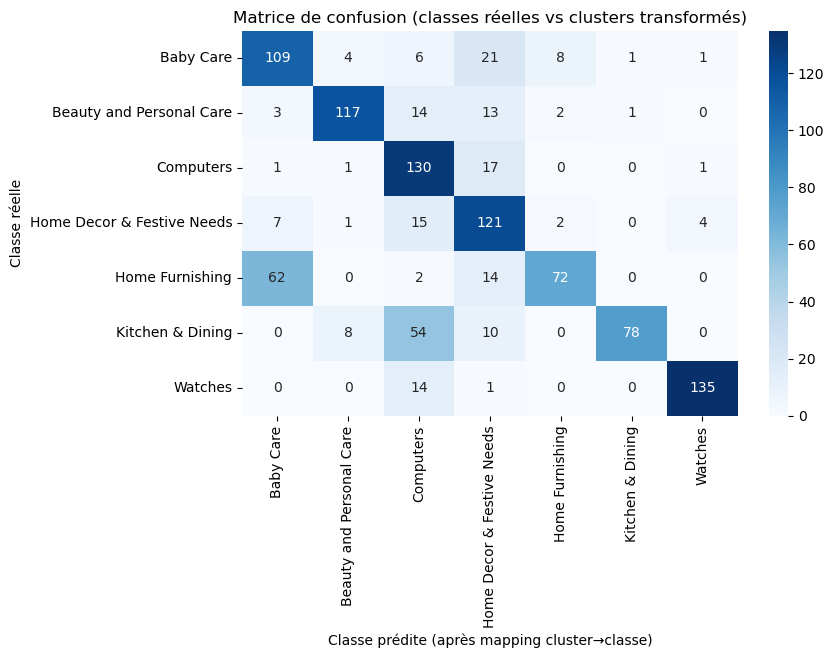

In [30]:
# Heatmap (lisible) — version “7 classes”

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_cm = pd.DataFrame(conf_mat, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8,5))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion (classes réelles vs clusters transformés)")
plt.xlabel("Classe prédite (après mapping cluster→classe)")
plt.ylabel("Classe réelle")
plt.show()

La matrice montre une forte diagonale, ce qui signifie que les clusters issus du T-SNE + KMeans correspondent globalement bien aux vraies catégories principales.

Catégories très bien séparées

Watches: Excellente séparabilité visuelle et sémantique (Watches → 135 correctement classés
Quasi aucune confusion)

Watches: Les produits informatiques ont une forte cohérence visuelle (130 correctement classés
Très peu d’erreurs)

Beauty and Personal Care: Bon regroupement visuel (117 bien classés
Très peu de confusion)

x Home Furnishing: Home Furnishing ↔ Baby Care, le modèle ne voit que la structure visuelle, pas l’usage du produit. (Home Furnishing → 62 classés comme Baby Care)

x Kitchen & Dining: Le modèle apprend la géométrie et la texture, pas la fonction (Kitchen & Dining → 54 confondus avec Computers)

Les features extraites par VGG16 capturent des caractéristiques visuelles suffisamment riches pour séparer automatiquement plusieurs grandes familles de produits.

Une classification supervisée basée sur ces embeddings CNN a un fort potentiel de performance car:

Si les clusters non supervisés sont déjà proches des vraies classes

Alors un modèle supervisé pourra apprendre des frontières bien plus précises